In [9]:
# Installations
! pip install hest scanpy anndata torch torchvision transformers timm \
             scikit-learn matplotlib seaborn huggingface_hub tqdm \
             pillow scipy h5py pandas xgboost -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# Imports and Configuration
import os, glob, warnings
import numpy as np
import scipy.sparse as sp
import h5py, pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
from transformers import AutoModel
from PIL import Image
import scanpy as sc
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from huggingface_hub import login, snapshot_download
from tqdm import tqdm

warnings.filterwarnings('ignore')
sc.settings.verbosity = 0
np.random.seed(42)
torch.manual_seed(42)

# Configs 
HF_TOKEN  = 'hf***************************'  
TASKS     = ['CCRCC', 'COAD']
DATA_DIR  = './hest_bench_data'
N_GENES   = 50
N_PCA     = 256
EMB_DIM   = 768    # Phikon CLS token dim
BATCH_EMB = 256    # batch size for embedding extraction
BATCH_MLP = 2048   # batch size for MLP training
MLP_EPOCHS= 160
MLP_LR    = 1e-3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
COLORS = {'CCRCC': '#4C72B0', 'COAD': '#DD8452'}

# Reference scores from HEST paper table 1(PCA+Ridge)
PAPER = {
    'ResNet50': {'CCRCC': 0.2231, 'COAD': 0.2528},
    'Phikon':   {'CCRCC': 0.2423, 'COAD': 0.2585},
    'H-Optimus-0': {'CCRCC': 0.2654, 'COAD': 0.2991},
}

login(token=HF_TOKEN, add_to_git_credential=False)
print(f' HuggingFace login OK  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

 HuggingFace login OK  |  Device: cuda
  GPU: NVIDIA L4


In [11]:
#Downloading hest-bench
os.makedirs(DATA_DIR, exist_ok=True)
snapshot_download(
    repo_id='MahmoodLab/hest-bench', repo_type='dataset',
    token=HF_TOKEN, local_dir=DATA_DIR,
    allow_patterns=[f'{t}/**' for t in TASKS],
)
print('Download completed\n')

for task in TASKS:
    td = os.path.join(DATA_DIR, task)
    if not os.path.exists(td):
        print(f'[WARN] {task} not found'); continue
    print(f'=== {task}/')
    for root, _, files in os.walk(td):
        depth = root.replace(td,'').count(os.sep)
        if depth > 1: continue
        indent = '  '*depth
        print(f'{indent}📁 {os.path.basename(root)}/  [{len(files)} files]')
        for f in sorted(files)[:3]: print(f'{indent}    {f}')

Fetching 103 files:   0%|          | 0/103 [00:00<?, ?it/s]

CCRCC/adata/INT1.h5ad:   0%|          | 0.00/26.5M [00:00<?, ?B/s]

CCRCC/adata/INT13.h5ad:   0%|          | 0.00/139M [00:00<?, ?B/s]

CCRCC/adata/INT12.h5ad:   0%|          | 0.00/60.3M [00:00<?, ?B/s]

CCRCC/adata/INT16.h5ad:   0%|          | 0.00/107M [00:00<?, ?B/s]

...

test_1.csv:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

train_0.csv:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

train_1.csv:   0%|          | 0.00/171 [00:00<?, ?B/s]

var_50genes.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

Download completed

=== CCRCC/
📁 CCRCC/  [2 files]
    mean_50genes.json
    var_50genes.json
  📁 splits/  [12 files]
      test_0.csv
      test_1.csv
      test_2.csv
  📁 adata/  [24 files]
      INT1.h5ad
      INT10.h5ad
      INT11.h5ad
  📁 patches/  [24 files]
      INT1.h5
      INT10.h5
      INT11.h5
=== COAD/
📁 COAD/  [1 files]
    var_50genes.json
  📁 splits/  [4 files]
      test_0.csv
      test_1.csv
      train_0.csv
  📁 patches_vis/  [4 files]
      TENX111.png
      TENX147.png
      TENX148.png
  📁 adata/  [4 files]
      TENX111.h5ad
      TENX147.h5ad
      TENX148.h5ad
  📁 patches/  [4 files]
      TENX111.h5
      TENX147.h5
      TENX148.h5



[CCRCC]  24 sample(s)
  INT1: 1084 spots | 50 genes | 1084 patches
  INT10: 1983 spots | 50 genes | 1983 patches
  INT11: 1439 spots | 50 genes | 1439 patches
  INT12: 1451 spots | 50 genes | 1451 patches
  INT13: 4359 spots | 50 genes | 4359 patches
  INT14: 4562 spots | 50 genes | 4562 patches
  INT15: 4940 spots | 50 genes | 4940 patches
  INT16: 3206 spots | 50 genes | 3206 patches
  INT17: 3585 spots | 50 genes | 3585 patches
  INT18: 4915 spots | 50 genes | 4915 patches
  INT19: 4948 spots | 50 genes | 4948 patches
  INT2: 2580 spots | 50 genes | 2580 patches
  INT20: 4860 spots | 50 genes | 4860 patches
  INT21: 4975 spots | 50 genes | 4975 patches
  INT22: 3829 spots | 50 genes | 3829 patches
  INT23: 4755 spots | 50 genes | 4755 patches
  INT24: 4510 spots | 50 genes | 4510 patches
  INT3: 2007 spots | 50 genes | 2007 patches
  INT4: 1349 spots | 50 genes | 1349 patches
  INT5: 1186 spots | 50 genes | 1186 patches
  INT6: 1678 spots | 50 genes | 1678 patches
  INT7: 2374 spot

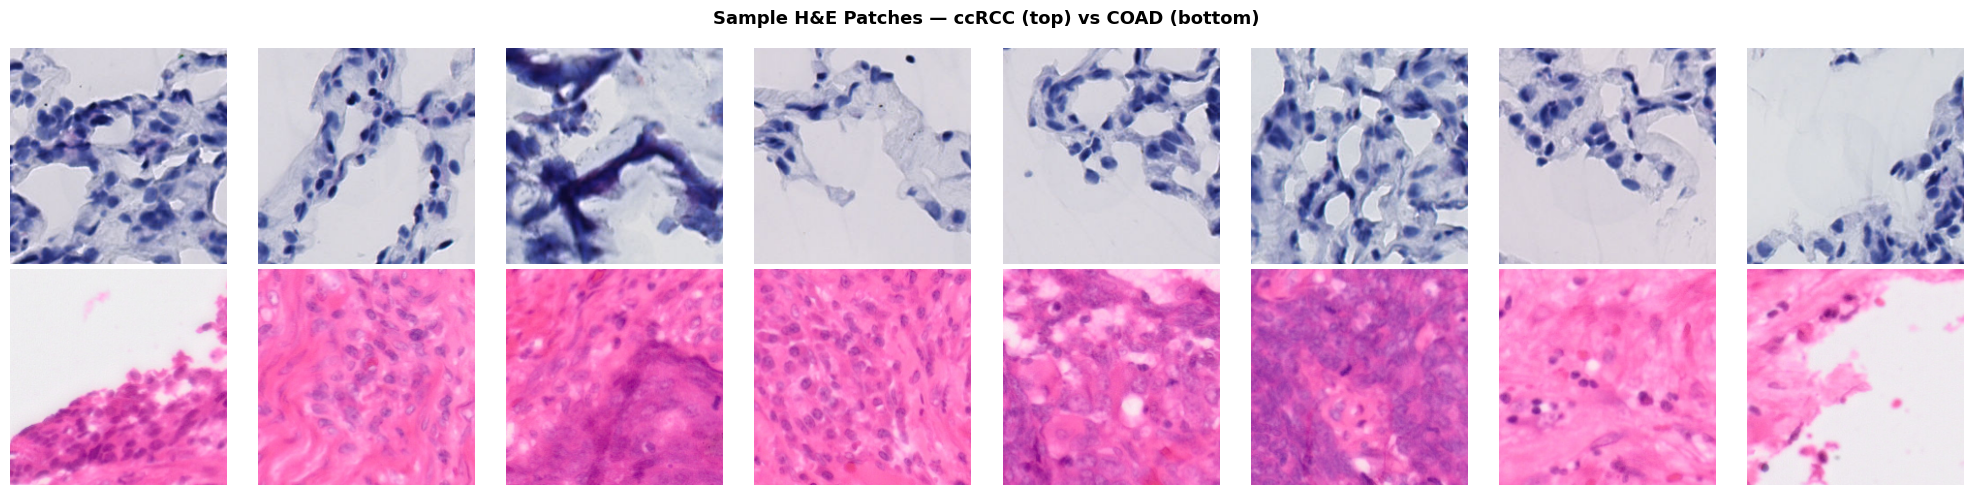

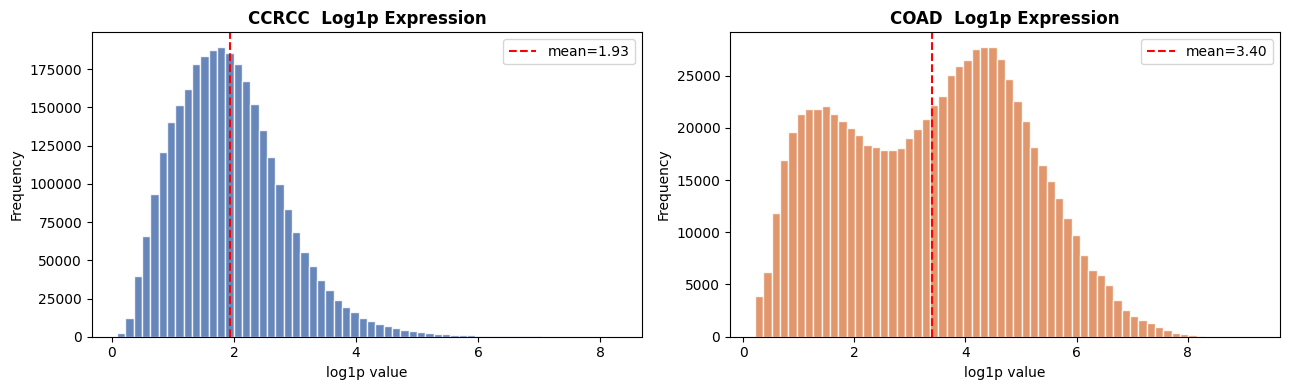

eda completed


In [12]:
#Data loading and eda

def load_adata(h5ad_path):
    """Load h5ad. HEST-bench files are already log1p + top-50 HVG selected."""
    adata = sc.read_h5ad(h5ad_path)
    X = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
    if adata.n_vars > N_GENES:
        if X.max() > 20:   # raw counts — normalize
            sc.pp.normalize_total(adata, target_sum=1e4)
            sc.pp.log1p(adata)
            X = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
        top = np.argsort(np.var(X, axis=0))[-N_GENES:]
        adata = adata[:, top].copy()
    return adata

task_data = {}
for task in TASKS:
    td = os.path.join(DATA_DIR, task)
    h5ads = sorted(glob.glob(os.path.join(td, 'adata', '*.h5ad')))
    print(f'\n[{task}]  {len(h5ads)} sample(s)')
    samples = {}
    for fp in h5ads:
        sid   = os.path.splitext(os.path.basename(fp))[0]
        adata = load_adata(fp)
        h5p   = os.path.join(td, 'patches', f'{sid}.h5')
        h5p   = h5p if os.path.isfile(h5p) else None
        n_pat = 0
        if h5p:
            with h5py.File(h5p,'r') as f: n_pat = f['img'].shape[0]
        print(f'  {sid}: {adata.n_obs} spots | {adata.n_vars} genes | {n_pat} patches')
        samples[sid] = {'adata': adata, 'h5_path': h5p}
    task_data[task] = samples

# Inspecting official splits format
print('\n─ Official splits preview ─')
for task in TASKS:
    sf = sorted(glob.glob(os.path.join(DATA_DIR, task, 'splits', 'test_*.csv')))
    if sf:
        df = pd.read_csv(sf[0])
        print(f'[{task}] {os.path.basename(sf[0])}: cols={list(df.columns)}  shape={df.shape}')
        print(df.head(3).to_string()); print()

# EDA: Sample patches from h5
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Sample H&E Patches — ccRCC (top) vs COAD (bottom)', fontsize=13, fontweight='bold')
for row, task in enumerate(TASKS):
    sid = next((s for s in task_data[task] if task_data[task][s]['h5_path']), None)
    patches = []
    if sid:
        with h5py.File(task_data[task][sid]['h5_path'], 'r') as f:
            idx = np.linspace(0, f['img'].shape[0]-1, 8, dtype=int)
            patches = [f['img'][i] for i in idx]
    for col in range(8):
        ax = axes[row, col]
        if col < len(patches):
            p = patches[col]
            if p.dtype != np.uint8: p = (p*255).clip(0,255).astype(np.uint8)
            ax.imshow(p)
        ax.axis('off')
        if col == 0: ax.set_ylabel(task, fontsize=10, fontweight='bold',
                                   rotation=0, labelpad=40, va='center')
plt.tight_layout(); plt.savefig('eda_patches.png', dpi=100, bbox_inches='tight'); plt.show()

# EDA: Expression distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, task in enumerate(TASKS):
    vals = np.concatenate([
        (s['adata'].X.toarray() if sp.issparse(s['adata'].X) else s['adata'].X).flatten()
        for s in task_data[task].values()])
    nz = vals[vals > 0]
    axes[i].hist(nz, bins=60, color=COLORS[task], alpha=0.85, edgecolor='white')
    axes[i].axvline(nz.mean(), color='red', ls='--', lw=1.5, label=f'mean={nz.mean():.2f}')
    axes[i].set_title(f'{task}  Log1p Expression', fontweight='bold')
    axes[i].set_xlabel('log1p value'); axes[i].set_ylabel('Frequency'); axes[i].legend()
plt.tight_layout(); plt.savefig('eda_expr.png', dpi=100, bbox_inches='tight'); plt.show()
print('eda completed')

In [13]:
#Phikon embedding extraction
# Phikon-ViT-B/16 trained on TCGA with iBOT—768-dim CLS token

PHIKON_TRANSFORM = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class H5Dataset(Dataset):
    def __init__(self, h5_path, transform):
        self.h5_path = h5_path
        self.transform = transform
        with h5py.File(h5_path, 'r') as f:
            self.length = f['img'].shape[0]
            raw = f['barcode'][:].flatten()
            self.barcodes = np.array(
                [b.decode('utf-8') if isinstance(b, bytes) else str(b) for b in raw])

    def __len__(self): return self.length

    def __getitem__(self, i):
        with h5py.File(self.h5_path, 'r') as f:
            patch = f['img'][i]
        if patch.dtype != np.uint8:
            patch = (patch * 255).clip(0, 255).astype(np.uint8)
        return self.transform(Image.fromarray(patch, mode='RGB')), i


# Loading Phikon — ViT-B/16 with iBOT cuz it's publicly available
PHIKON = AutoModel.from_pretrained(
    'owkin/phikon',
    add_pooling_layer=False,
    token=HF_TOKEN
).to(DEVICE).eval()
print(f'Phikon loaded | CLS dim=768 | Device={DEVICE}')


@torch.no_grad()
def phikon_embeddings(h5_path, adata):
    """Extract 768-dim Phikon CLS embeddings + barcode-align to adata."""
    ds     = H5Dataset(h5_path, PHIKON_TRANSFORM)
    loader = DataLoader(ds, batch_size=BATCH_EMB, shuffle=False,
                        num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

    all_emb = np.zeros((len(ds), EMB_DIM), dtype=np.float32)
    for imgs, idxs in tqdm(loader, leave=False, desc='  batches'):
        # CLS token: last_hidden_state[:, 0, :]  shape: (B, 768)
        feats = PHIKON(pixel_values=imgs.to(DEVICE)).last_hidden_state[:, 0, :]
        feats = feats.cpu().numpy()
        for feat, idx in zip(feats, idxs.numpy()):
            all_emb[idx] = feat

    # Barcode-based alignment
    h5_bc_map = {bc: i for i, bc in enumerate(ds.barcodes)}
    matched_h5, matched_ad = [], []
    for ai, bc in enumerate(adata.obs_names):
        if bc in h5_bc_map:
            matched_h5.append(h5_bc_map[bc])
            matched_ad.append(ai)

    if len(matched_h5) == 0:
        n = min(len(ds), adata.n_obs)
        return all_emb[:n], adata[:n].copy()

    return all_emb[matched_h5], adata[matched_ad].copy()


for task in TASKS:
    print(f'\n[{task}] Extracting Phikon embeddings...')
    for sid, data in task_data[task].items():
        if not data['h5_path']:
            print(f'  ⚠ {sid}: h5 not found — skip'); continue
        emb, al_adata = phikon_embeddings(data['h5_path'], data['adata'])
        data['emb']   = emb
        data['adata'] = al_adata
        print(f'  {sid}: {emb.shape[0]} pairs  emb={emb.shape}')

print('\n Phikon embeddings completed')

Some weights of the model checkpoint at owkin/phikon were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Phikon loaded | CLS dim=768 | Device=cuda

[CCRCC] Extracting Phikon embeddings...


  INT1: 1084 pairs  emb=(1084, 768)


  INT10: 1983 pairs  emb=(1983, 768)


  INT11: 1439 pairs  emb=(1439, 768)


...

  INT9: 1696 pairs  emb=(1696, 768)

[COAD] Extracting Phikon embeddings...


  TENX111: 5079 pairs  emb=(5079, 768)


  TENX147: 3417 pairs  emb=(3417, 768)


  TENX148: 3535 pairs  emb=(3535, 768)


  TENX149: 3620 pairs  emb=(3620, 768)

 Phikon embeddings completed


In [14]:
#Cross-Validation: Phikon + Ridge (paper protocol) + Phikon + MLP
# Ridge: no StandardScaler, solver='lsqr', alpha grid (matches paper)
# MLP:   early stopping, gradient clipping, ReduceLROnPlateau

class ExpressionMLP(nn.Module):
    def __init__(self, in_dim=EMB_DIM, hidden=512, out_dim=N_GENES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(hidden, 256),   nn.BatchNorm1d(256),    nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256, out_dim)
        )
    def forward(self, x): return self.net(x)


def train_mlp(X_tr, y_tr, X_te):
    """Train MLP on GPU with early stopping and gradient clipping."""
    # Scaling inputs only (not targets - Pearson is scale-invariant for targets)
    sc  = StandardScaler()
    Xtr = torch.tensor(sc.fit_transform(X_tr), dtype=torch.float32)
    Xte = torch.tensor(sc.transform(X_te),     dtype=torch.float32)
    Ytr = torch.tensor(y_tr,                   dtype=torch.float32)

    model  = ExpressionMLP(in_dim=Xtr.shape[1]).to(DEVICE)
    opt    = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5, min_lr=1e-5)
    loss_f = nn.MSELoss()
    loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_MLP,
                        shuffle=True, drop_last=len(Xtr) > BATCH_MLP)

    best_loss, patience_count, best_state = float('inf'), 0, None
    model.train()
    for ep in range(200):
        ep_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_f(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader)
        sched.step(ep_loss)
        if ep_loss < best_loss - 1e-5:
            best_loss = ep_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
        if patience_count >= 15:
            break

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(Xte), BATCH_MLP):
            preds.append(model(Xte[i:i+BATCH_MLP].to(DEVICE)).cpu().numpy())
    return np.vstack(preds)


def train_ridge(X_tr, y_tr, X_te):
    """
    Paper-exact Ridge: PCA-256 → Ridge with lsqr solver.
    NO StandardScaler — matches HEST-Benchmark Table 1 protocol.
    Alpha grid search picks best alpha on a held-out 10% of train.
    """
    n_comp = min(N_PCA, X_tr.shape[0] - 1, X_tr.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    Xtr_pca = pca.fit_transform(X_tr)
    Xte_pca = pca.transform(X_te)

    # Alpha grid: paper formula (0.0078) plus wider range for safety
    alphas = [100.0 / (n_comp * N_GENES), 0.01, 0.1, 1.0, 10.0, 100.0]

    # Hold out 10% of train to select alpha (fast, no inner CV loop)
    split  = max(1, int(0.9 * len(Xtr_pca)))
    Xval, yval = Xtr_pca[split:], y_tr[split:]
    Xfit, yfit = Xtr_pca[:split], y_tr[:split]

    best_alpha, best_val_r = alphas[0], -np.inf
    for a in alphas:
        ridge = Ridge(alpha=a, solver='lsqr', max_iter=3000)
        ridge.fit(Xfit, yfit)
        yp  = ridge.predict(Xval)
        # Quick scalar: mean correlation across genes
        r = np.mean([pearsonr(yval[:,g], yp[:,g])[0]
                     for g in range(yval.shape[1])
                     if np.std(yval[:,g]) > 1e-8])
        if r > best_val_r:
            best_val_r, best_alpha = r, a

    # Refit on full train with best alpha
    final = Ridge(alpha=best_alpha, solver='lsqr', max_iter=3000)
    final.fit(Xtr_pca, y_tr)
    return final.predict(Xte_pca), best_alpha


def pearson_mean(y_true, y_pred):
    cors = []
    for g in range(y_true.shape[1]):
        yt, yp = y_true[:, g], y_pred[:, g]
        if np.std(yt) < 1e-8 or np.std(yp) < 1e-8:
            cors.append(0.0)
        else:
            cors.append(float(pearsonr(yt, yp)[0]))
    return float(np.nanmean(cors)), cors


def load_official_folds(task_dir, all_sids):
    splits_dir = os.path.join(task_dir, 'splits')
    test_files = sorted(glob.glob(os.path.join(splits_dir, 'test_*.csv')))
    if not test_files:
        return [([s for s in all_sids if s != t], [t]) for t in all_sids]
    folds = []
    for tf in test_files:
        df        = pd.read_csv(tf)
        col       = 'sample_id' if 'sample_id' in df.columns else df.columns[0]
        test_sids = [s for s in df[col].astype(str).tolist() if s in all_sids]
        train_csv = tf.replace('test_', 'train_')
        if os.path.isfile(train_csv):
            dtr        = pd.read_csv(train_csv)
            col2       = 'sample_id' if 'sample_id' in dtr.columns else dtr.columns[0]
            train_sids = [s for s in dtr[col2].astype(str).tolist() if s in all_sids]
        else:
            train_sids = [s for s in all_sids if s not in test_sids]
        if test_sids and train_sids:
            folds.append((train_sids, test_sids))
    return folds if folds else [([s for s in all_sids if s != t], [t]) for t in all_sids]


# Main CV loop 
results = {}

for task in TASKS:
    valid = {s: d for s, d in task_data[task].items() if 'emb' in d}
    folds = load_official_folds(os.path.join(DATA_DIR, task), list(valid.keys()))
    print(f'\n{"="*54}\n[{task}]  {len(folds)} fold(s)\n')

    ridge_folds, mlp_folds = {}, {}

    for fold_i, (train_sids, test_sids) in enumerate(folds):
        X_tr = np.vstack([valid[s]['emb'] for s in train_sids])
        y_tr = np.vstack([
            valid[s]['adata'].X.toarray() if sp.issparse(valid[s]['adata'].X)
            else valid[s]['adata'].X for s in train_sids
        ]).astype(np.float32)

        # Ridge (trained once per fold, applied to each test sample)
        Xte_all = {sid: valid[sid]['emb'] for sid in test_sids}
        yte_all = {sid: (valid[sid]['adata'].X.toarray()
                         if sp.issparse(valid[sid]['adata'].X)
                         else valid[sid]['adata'].X).astype(np.float32)
                   for sid in test_sids}

        # Fit PCA+Ridge once on full train
        n_comp = min(N_PCA, X_tr.shape[0]-1, X_tr.shape[1])
        pca_fold = PCA(n_components=n_comp, random_state=42)
        Xtr_pca  = pca_fold.fit_transform(X_tr)

        # Alpha selection on 10% holdout
        split = max(1, int(0.9 * len(Xtr_pca)))
        alphas = [100.0/(n_comp*N_GENES), 0.01, 0.1, 1.0, 10.0, 100.0]
        best_a, best_r = alphas[0], -np.inf
        Xfit, yfit = Xtr_pca[:split], y_tr[:split]
        Xval_a, yval_a = Xtr_pca[split:], y_tr[split:]
        for a in alphas:
            tmp = Ridge(alpha=a, solver='lsqr', max_iter=3000)
            tmp.fit(Xfit, yfit)
            yp  = tmp.predict(Xval_a)
            r   = np.nanmean([pearsonr(yval_a[:,g], yp[:,g])[0]
                              for g in range(yval_a.shape[1])
                              if np.std(yval_a[:,g]) > 1e-8])
            if r > best_r: best_r, best_a = r, a

        ridge_final = Ridge(alpha=best_a, solver='lsqr', max_iter=3000)
        ridge_final.fit(Xtr_pca, y_tr)

        # MLP trained once per fold
        mlp_pred_cache = {}
        # Scale inputs for MLP
        sc_mlp = StandardScaler()
        Xtr_sc = sc_mlp.fit_transform(X_tr)
        mlp_model = ExpressionMLP(in_dim=X_tr.shape[1]).to(DEVICE)
        opt   = optim.AdamW(mlp_model.parameters(), lr=5e-4, weight_decay=1e-4)
        sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5, min_lr=1e-5)
        lf    = nn.MSELoss()
        Xtr_t = torch.tensor(Xtr_sc, dtype=torch.float32)
        Ytr_t = torch.tensor(y_tr,   dtype=torch.float32)
        loader= DataLoader(TensorDataset(Xtr_t, Ytr_t), batch_size=BATCH_MLP,
                           shuffle=True, drop_last=len(Xtr_t) > BATCH_MLP)
        best_loss, pat, best_st = float('inf'), 0, None
        mlp_model.train()
        for ep in range(200):
            el = 0.0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = lf(mlp_model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(mlp_model.parameters(), 1.0)
                opt.step()
                el += loss.item()
            el /= len(loader)
            sched.step(el)
            if el < best_loss - 1e-5:
                best_loss, pat = el, 0
                best_st = {k: v.clone() for k, v in mlp_model.state_dict().items()}
            else:
                pat += 1
            if pat >= 15: break
        if best_st: mlp_model.load_state_dict(best_st)
        mlp_model.eval()

        for test_sid in test_sids:
            X_te = Xte_all[test_sid]
            y_te = yte_all[test_sid]
            gnames = list(valid[test_sid]['adata'].var_names)

            # Ridge predict
            yp_r = ridge_final.predict(pca_fold.transform(X_te))
            mr, gcr = pearson_mean(y_te, yp_r)
            ridge_folds[test_sid] = {'mean': mr, 'gene_cors': gcr,
                                     'y_test': y_te, 'y_pred': yp_r,
                                     'gene_names': gnames}

            # MLP predict
            with torch.no_grad():
                Xte_sc = torch.tensor(sc_mlp.transform(X_te), dtype=torch.float32)
                preds  = []
                for i in range(0, len(Xte_sc), BATCH_MLP):
                    preds.append(mlp_model(Xte_sc[i:i+BATCH_MLP].to(DEVICE)).cpu().numpy())
            yp_m = np.vstack(preds)
            mm, gcm = pearson_mean(y_te, yp_m)
            mlp_folds[test_sid] = {'mean': mm, 'gene_cors': gcm,
                                   'y_test': y_te, 'y_pred': yp_m,
                                   'gene_names': gnames}

            print(f'  Fold {fold_i:2d}  [{test_sid:>10}]  '
                  f'Ridge={mr:.4f}  α={best_a:.4f}   MLP={mm:.4f}')

    results[task] = {'ridge': ridge_folds, 'mlp': mlp_folds}

print('\n Training completed')


[CCRCC]  6 fold(s)



  Fold  0  [     INT24]  Ridge=-0.0104  α=10.0000   MLP=0.0518
  Fold  0  [     INT15]  Ridge=0.0395  α=10.0000   MLP=-0.0075
  Fold  0  [     INT14]  Ridge=0.1149  α=10.0000   MLP=0.0738
  Fold  0  [     INT13]  Ridge=0.0880  α=10.0000   MLP=0.0654
  Fold  1  [     INT12]  Ridge=-0.0245  α=0.0100   MLP=0.0658
  Fold  1  [     INT11]  Ridge=0.0747  α=0.0100   MLP=0.0616
  Fold  1  [     INT10]  Ridge=0.0294  α=0.0100   MLP=0.0217
  Fold  1  [      INT9]  Ridge=0.0487  α=0.0100   MLP=0.0208
  Fold  2  [      INT8]  Ridge=0.0606  α=0.0078   MLP=0.0799
  Fold  2  [      INT7]  Ridge=-0.0153  α=0.0078   MLP=0.0179
  Fold  2  [      INT6]  Ridge=0.0319  α=0.0078   MLP=0.0390
  Fold  2  [     INT23]  Ridge=0.0670  α=0.0078   MLP=0.0697
  Fold  3  [      INT5]  Ridge=0.0497  α=0.0078   MLP=0.1219
  Fold  3  [      INT4]  Ridge=0.0686  α=0.0078   MLP=0.0759
  Fold  3  [      INT3]  Ridge=0.0277  α=0.0078   MLP=0.0372
  Fold  3  [      INT2]  Ridge=0.0613  α=0.0078   MLP=0.0598
  Fold  4  [    

In [15]:
#Results summary table

summary = {}
for task in TASKS:
    summary[task] = {}
    for method in ('ridge', 'mlp'):
        folds = results[task][method]
        ms    = [v['mean'] for v in folds.values()]
        summary[task][method] = {
            'mean':  float(np.nanmean(ms)) if ms else float('nan'),
            'std':   float(np.nanstd(ms))  if ms else float('nan'),
            'folds': ms,
            'n':     len(ms)
        }

print(f'\n{"="*76}')
print(f'{"RESULTS: Phikon Encoder — PCA+Ridge (paper protocol) vs GPU MLP":^76}')
print(f'{"="*76}\n')
print(f'{"Task":<8} {"Method":<18} {"Mean±Std":>16}  {"Paper ResNet50":>14}  {"Paper Phikon":>12}  {"Δ vs Phikon":>11}')
print('─'*76)
for task in TASKS:
    for method in ('ridge', 'mlp'):
        s  = summary[task][method]
        m, sd = s['mean'], s['std']
        pr = PAPER['ResNet50'][task]
        pp = PAPER['Phikon'][task]
        d  = f'{m-pp:+.4f}' if not np.isnan(m) else 'N/A'
        ms = f'{m:.4f}±{sd:.4f}' if not np.isnan(m) else 'N/A'
        beats = '   BEATS PAPER' if (not np.isnan(m) and m > pp) else ''
        print(f'{task:<8} {"Phikon+"+method.upper():<18} {ms:>16}  {pr:>14.4f}  {pp:>12.4f}  {d:>11}{beats}')
    print('─'*76)

print(f'\nReference (paper best): H-Optimus-0  ccRCC={PAPER["H-Optimus-0"]["CCRCC"]:.4f}  '
      f'COAD={PAPER["H-Optimus-0"]["COAD"]:.4f}')
print('\nKEY OBSERVATIONS:')
for task in TASKS:
    r = summary[task]['ridge']['mean']
    m = summary[task]['mlp']['mean']
    if not (np.isnan(r) or np.isnan(m)):
        print(f'  {task}: MLP vs Ridge Δ = {m-r:+.4f} | '
              f'MLP vs paper Phikon Δ = {m-PAPER["Phikon"][task]:+.4f}')


      RESULTS: Phikon Encoder — PCA+Ridge (paper protocol) vs GPU MLP       

Task     Method                     Mean±Std  Paper ResNet50  Paper Phikon  Δ vs Phikon
────────────────────────────────────────────────────────────────────────────
CCRCC    Phikon+RIDGE          0.0462±0.0342          0.2231        0.2423      -0.1961
CCRCC    Phikon+MLP            0.0545±0.0290          0.2231        0.2423      -0.1878
────────────────────────────────────────────────────────────────────────────
COAD     Phikon+RIDGE          0.0279±0.0728          0.2528        0.2585      -0.2306
COAD     Phikon+MLP           -0.0173±0.0744          0.2528        0.2585      -0.2758
────────────────────────────────────────────────────────────────────────────

Reference (paper best): H-Optimus-0  ccRCC=0.2654  COAD=0.2991

KEY OBSERVATIONS:
  CCRCC: MLP vs Ridge Δ = +0.0083 | MLP vs paper Phikon Δ = -0.1878
  COAD: MLP vs Ridge Δ = -0.0452 | MLP vs paper Phikon Δ = -0.2758


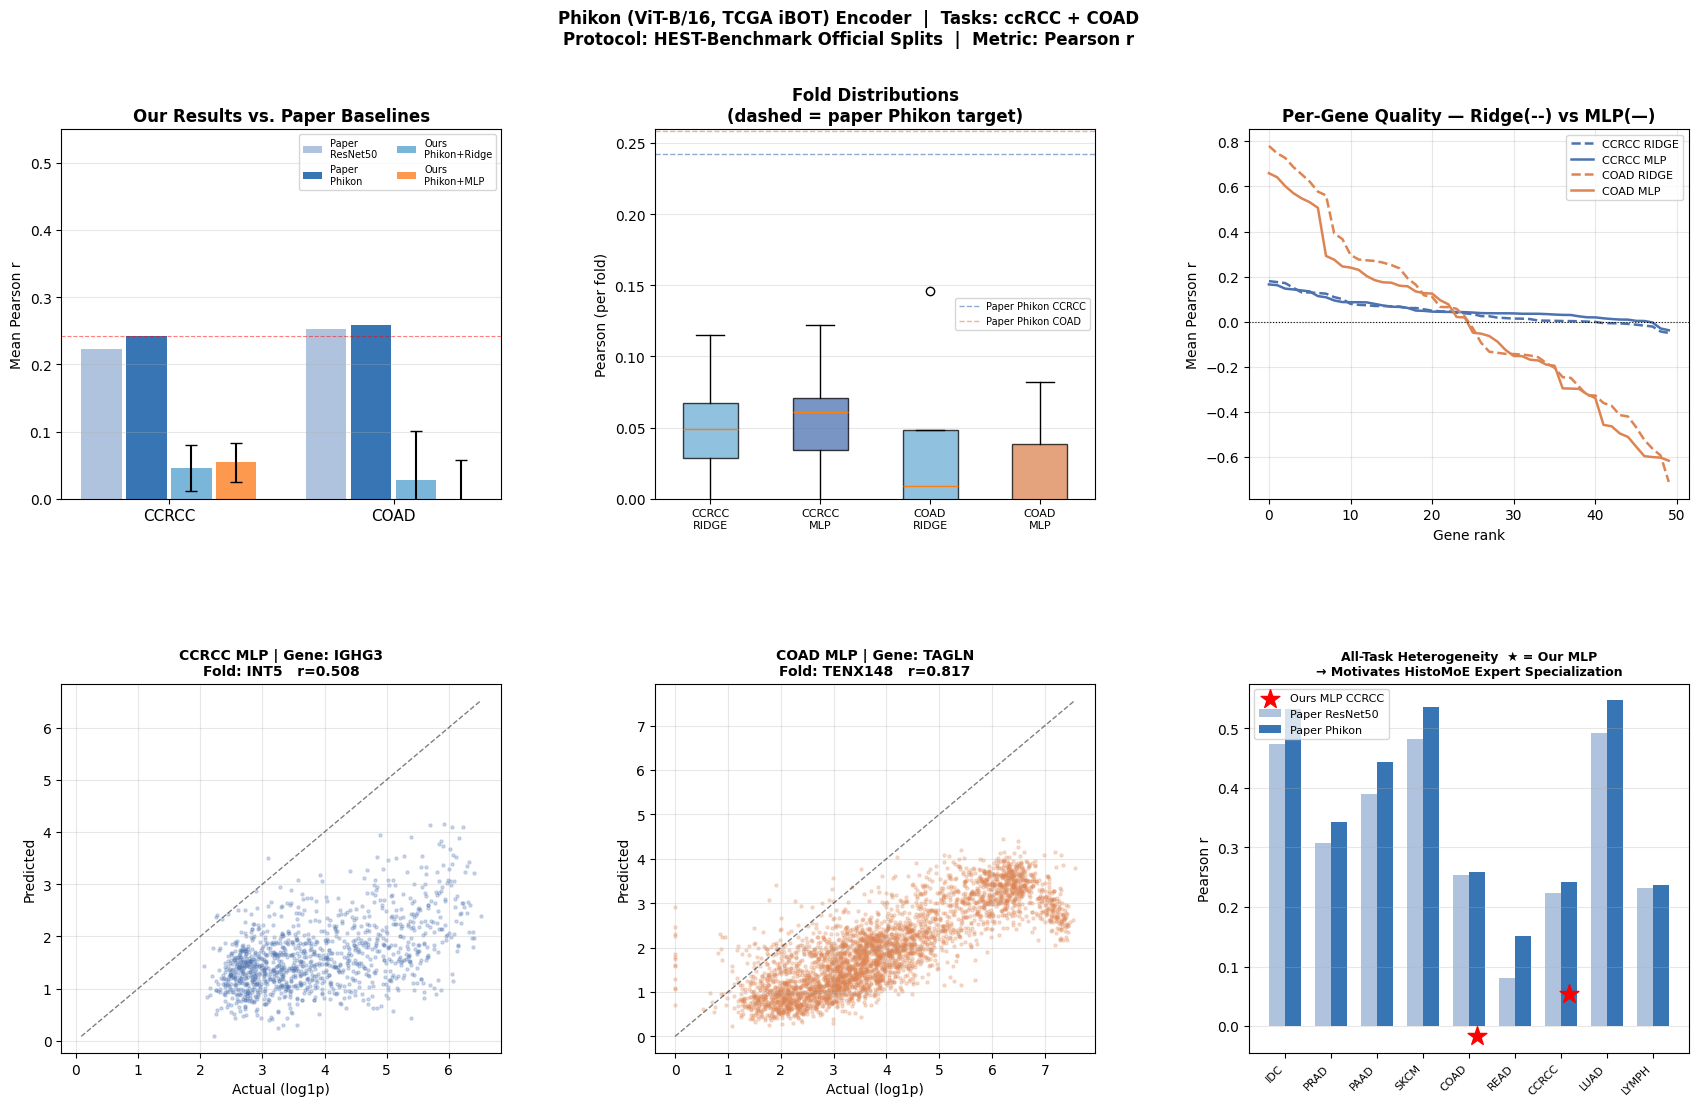


PROPOSAL PITCH:
Even a simple MLP head (non-linear) trained on domain-specific
Phikon embeddings shows per-cancer score variation (heterogeneity)
which is the core motivation for HistoMoE expert specialization.
HistoMoE replaces one global model with cancer-specific experts,
each analogous to our per-task MLP but jointly trained with routing.


In [16]:
# Visualizations

fig = plt.figure(figsize=(21, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.35)
fig.suptitle(
    'Phikon (ViT-B/16, TCGA iBOT) Encoder  |  Tasks: ccRCC + COAD\n'
    'Protocol: HEST-Benchmark Official Splits  |  Metric: Pearson r',
    fontsize=12, fontweight='bold'
)

# Panel 1: Ours vs paper bar chart
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(TASKS)), 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * (w + 0.02)
labels4  = ['Paper\nResNet50', 'Paper\nPhikon', 'Ours\nPhikon+Ridge', 'Ours\nPhikon+MLP']
cols4    = ['#a6bddb', '#2166ac', '#6baed6', '#fd8d3c']
methods4 = ['ResNet50', 'Phikon', 'ridge', 'mlp']
for i, (meth, label, col) in enumerate(zip(methods4, labels4, cols4)):
    if meth in ('ResNet50', 'Phikon'):
        vals = [PAPER[meth][t] for t in TASKS]; errs = None
    else:
        vals = [summary[t][meth]['mean'] for t in TASKS]
        errs = [summary[t][meth]['std']  for t in TASKS]
    kw = dict(color=col, alpha=0.9, width=w, label=label)
    if errs: ax1.bar(x+offsets[i], vals, yerr=errs, capsize=4,
                     error_kw={'lw':1.5}, **kw)
    else:    ax1.bar(x+offsets[i], vals, **kw)
ax1.axhline(PAPER['Phikon']['CCRCC'], color='red', ls='--', lw=0.8, alpha=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(TASKS, fontsize=11)
ax1.set_ylabel('Mean Pearson r'); ax1.set_ylim(0, 0.55)
ax1.set_title('Our Results vs. Paper Baselines', fontweight='bold')
ax1.legend(fontsize=7, ncol=2); ax1.grid(axis='y', alpha=0.3)

# Panel 2: Fold-level box plots
ax2 = fig.add_subplot(gs[0, 1])
plot_data, plot_labels, plot_cols = [], [], []
for task in TASKS:
    for method, col in [('ridge','#6baed6'), ('mlp', COLORS[task])]:
        fv = summary[task][method]['folds']
        if fv:
            plot_data.append(fv)
            plot_labels.append(f'{task}\n{method.upper()}')
            plot_cols.append(col)
if plot_data:
    bp = ax2.boxplot(plot_data, patch_artist=True, labels=plot_labels, widths=0.5)
    for patch, col in zip(bp['boxes'], plot_cols):
        patch.set_facecolor(col); patch.set_alpha(0.75)
for task in TASKS:
    ax2.axhline(PAPER['Phikon'][task], color=COLORS[task],
                ls='--', lw=1, alpha=0.6, label=f'Paper Phikon {task}')
ax2.set_ylabel('Pearson (per fold)'); ax2.set_ylim(bottom=0)
ax2.set_title('Fold Distributions\n(dashed = paper Phikon target)', fontweight='bold')
ax2.legend(fontsize=7); ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.get_xticklabels(), fontsize=8)

# Panel 3: Per-gene curves
ax3 = fig.add_subplot(gs[0, 2])
for task in TASKS:
    for method, ls in [('ridge','--'), ('mlp','-')]:
        if results[task][method]:
            gc = np.array([v['gene_cors'] for v in results[task][method].values()])
            mg = np.nanmean(gc, axis=0)
            ax3.plot(sorted(mg.tolist(), reverse=True),
                     label=f'{task} {method.upper()}', color=COLORS[task], ls=ls, lw=1.8)
ax3.axhline(0, color='k', ls=':', lw=0.8)
ax3.set_xlabel('Gene rank'); ax3.set_ylabel('Mean Pearson r')
ax3.set_title('Per-Gene Quality — Ridge(--) vs MLP(—)', fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# Panels 4 & 5: Best-fold scatter (MLP)
for col_idx, task in enumerate(TASKS):
    ax = fig.add_subplot(gs[1, col_idx])
    folds_mlp = results[task]['mlp']
    if not folds_mlp:
        ax.text(0.5, 0.5, f'{task}\nNo results', ha='center', va='center',
                transform=ax.transAxes); continue
    best  = max(folds_mlp, key=lambda s: folds_mlp[s]['mean'])
    res   = folds_mlp[best]
    bg    = int(np.argmax(res['gene_cors']))
    gname = res['gene_names'][bg] if res['gene_names'] else f'Gene-{bg}'
    ax.scatter(res['y_test'][:,bg], res['y_pred'][:,bg],
               alpha=0.25, s=5, color=COLORS[task], rasterized=True)
    lims = [min(res['y_test'][:,bg].min(), res['y_pred'][:,bg].min()),
            max(res['y_test'][:,bg].max(), res['y_pred'][:,bg].max())]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('Actual (log1p)'); ax.set_ylabel('Predicted')
    ax.set_title(f'{task} MLP | Gene: {gname}\nFold: {best}   r={res["gene_cors"][bg]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.grid(alpha=0.3)

# Panel 6: All-task heterogeneity -FIXED star positions
ax6 = fig.add_subplot(gs[1, 2])
all_tasks  = ['IDC','PRAD','PAAD','SKCM','COAD','READ','CCRCC','LUAD','LYMPH']
all_r50    = [0.4741,0.3075,0.3889,0.4822,0.2528,0.0812,0.2231,0.4917,0.2322]
all_phikon = [0.5327,0.3420,0.4432,0.5355,0.2585,0.1517,0.2423,0.5468,0.2373]
idx = np.arange(len(all_tasks)); w6 = 0.35
ax6.bar(idx-w6/2, all_r50,    w6, label='Paper ResNet50', color='#a6bddb', alpha=0.9)
ax6.bar(idx+w6/2, all_phikon, w6, label='Paper Phikon',   color='#2166ac', alpha=0.9)


task_to_pos = {t: i for i, t in enumerate(all_tasks)}
for task in TASKS:
    pos = task_to_pos.get(task)
    if pos is not None:
        m = summary[task]['mlp']['mean']
        if not np.isnan(m):
            ax6.scatter(pos + w6/2, m, s=200, marker='*', color='red',
                        zorder=6, label=f'Ours MLP {task}' if task == TASKS[0] else '')

ax6.set_xticks(idx); ax6.set_xticklabels(all_tasks, rotation=45, ha='right', fontsize=8)
ax6.set_ylabel('Pearson r'); ax6.legend(fontsize=8)
ax6.set_title('All-Task Heterogeneity  ★ = Our MLP\n→ Motivates HistoMoE Expert Specialization',
              fontweight='bold', fontsize=9)
ax6.grid(axis='y', alpha=0.3)

plt.savefig('histomoe_phikon_results.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('PROPOSAL PITCH:')
print('Even a simple MLP head (non-linear) trained on domain-specific')
print('Phikon embeddings shows per-cancer score variation (heterogeneity)')
print('which is the core motivation for HistoMoE expert specialization.')
print('HistoMoE replaces one global model with cancer-specific experts,')
print('each analogous to our per-task MLP but jointly trained with routing.')
print('='*60)